<a href="https://colab.research.google.com/github/hasby-umutoniwabo/IntroToMl_summative/blob/main/mooc_dropout_prediction_summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MOOC Dropout Prediction: A Machine Learning & Deep Learning Comparison

**Author:** Hasbiyallah Umutoniwabo
**Course:** Introduction to Machine Learning — Summative Final Project
**Mission alignment:** Tech for Good — Digital Literacy & Education Access

---

### Problem Statement
Massive Open Online Courses (MOOCs) promise to democratize education, but most courses suffer
from extremely high dropout rates. Predicting *which* students are likely to drop out early
allows platforms to intervene (reminders, support, simplified content) before the student
disengages completely. This directly supports digital literacy and education-access goals by
helping more learners actually *finish* what they start.

### Dataset
[MOOC Dataset (Kaggle)](https://www.kaggle.com/datasets/kanikanarang94/mooc-dataset) — built from
the HarvardX/MITx 2012–2013 open edX data release, containing learner activity and outcome data
for MOOC courses.

### What this notebook does
1. Loads the dataset directly from Kaggle (no manual file upload needed)
2. Cleans and explores the data
3. Builds a **stratified subsample** for fast, free-tier-friendly experimentation
4. Trains and compares **classical ML models (Scikit-learn)** vs **Deep Learning models (TensorFlow — Sequential & Functional APIs, tf.data)**
5. Runs multiple experiments, interprets results, and analyzes errors


## Part 1 — Setup & Imports

**What's happening here:** We're installing/importing every library we'll need up front, so the
notebook runs cleanly top-to-bottom on a fresh Colab session. `kagglehub` is Kaggle's official tool
for pulling datasets straight into a notebook — no manual downloading required.

In [1]:
# Install kagglehub
!pip install -q kagglehub


In [2]:
# Core libraries for data handling and math
import numpy as np
import pandas as pd

# Plotting —  (for learning curves, confusion matrices, ROC curves)
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: same random seed everywhere so results don't change between runs
SEED = 42
np.random.seed(SEED)

# Decorating plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Setup complete. Random seed fixed at", SEED)


Setup complete. Random seed fixed at 42


## Part 2 — Load the Dataset

**One-time setup (only needed the first time you run this notebook):**
1. Create a free account at [kaggle.com](https://www.kaggle.com) if you don't have one
2. Go to **Account Settings → API → Create New Token** — this downloads a small `kaggle.json` file
3. When you run the cell below, Colab will prompt you to upload that file (or it will open a login window)

This is the *standard*, official way to pull any Kaggle dataset into a notebook — it's what
Kaggle itself recommends for reproducibility, so anyone opening this notebook can run it
end-to-end without needing my personal files.

In [3]:
import kagglehub

# Downloads the dataset directly from Kaggle and returns the local folder path
dataset_path = kagglehub.dataset_download("kanikanarang94/mooc-dataset")

print("Dataset downloaded to:", dataset_path)


Using Colab cache for faster access to the 'mooc-dataset' dataset.
Dataset downloaded to: /kaggle/input/mooc-dataset


In [4]:
# Files that came with the dataset
import os

for file in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, file)
    size_mb = os.path.getsize(full_path) / (1024 * 1024)
    print(f"{file}  —  {size_mb:.2f} MB")


big_student_clear_third_version.csv  —  55.94 MB


**Note:** This dataset includes a few versions of the same cleaned data. We'll use
`big_student_clear_third_version.csv` — the main cleaned file most researchers use for this
dataset (confirmed via prior published work using this same Kaggle dataset). If the filename
differs slightly in your download, the cell below will catch it automatically.

In [5]:
# Automatically find the main CSV file (in case the exact filename varies slightly)
csv_candidates = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("CSV files found:", csv_candidates)

# Prefer the 'big_student_clear' file if present, otherwise just take the largest CSV
target_file = None
for f in csv_candidates:
    if "big_student_clear" in f.lower():
        target_file = f
        break
if target_file is None:
    target_file = max(csv_candidates, key=lambda f: os.path.getsize(os.path.join(dataset_path, f)))

csv_path = os.path.join(dataset_path, target_file)
print("\nUsing file:", target_file)

df = pd.read_csv(csv_path)
print("Shape (rows, columns):", df.shape)


CSV files found: ['big_student_clear_third_version.csv']

Using file: big_student_clear_third_version.csv
Shape (rows, columns): (416921, 22)


### First Look at the Data

In [6]:
# A quick peek at the first few rows
df.head()


,Unnamed: 0,institute,course_id,year,semester,userid_DI,viewed,explored,certified,final_cc_cname_DI,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age
0,4,HarvardX,PH207x,2012,Fall,MHxPC130313697,0,0,0,India,...,0.0,2012-07-24,2013-07-27,6,3,197757,0,0,0,23
1,6,HarvardX,PH207x,2012,Fall,MHxPC130237753,1,0,0,United States,...,0.0,2012-07-24,2012-12-24,107,8,7,2,0,0,19
2,7,HarvardX,CS50x,2012,Summer,MHxPC130202970,1,0,0,United States,...,0.0,2012-07-24,2013-03-28,8,1,197757,1,0,0,24
3,20,HarvardX,CS50x,2012,Summer,MHxPC130223941,1,0,0,Other Middle East/Central Asia,...,0.0,2012-07-24,2013-07-15,25,2,197757,4,0,0,20
4,22,HarvardX,PH207x,2012,Fall,MHxPC130317399,0,0,0,Australia,...,0.0,2012-07-24,2012-08-25,3,2,197757,0,0,0,32


In [7]:
# Column names, data types, and how many non-missing values each column has
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416921 entries, 0 to 416920
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         416921 non-null  int64  
 1   institute          416921 non-null  object 
 2   course_id          416921 non-null  object 
 3   year               416921 non-null  int64  
 4   semester           416921 non-null  object 
 5   userid_DI          416921 non-null  object 
 6   viewed             416921 non-null  int64  
 7   explored           416921 non-null  int64  
 8   certified          416921 non-null  int64  
 9   final_cc_cname_DI  416921 non-null  object 
 10  LoE_DI             416921 non-null  object 
 11  gender             393710 non-null  object 
 12  grade              416921 non-null  float64
 13  start_time_DI      416921 non-null  object 
 14  last_event_DI      416921 non-null  object 
 15  nevents            416921 non-null  int64  
 16  nd

In [8]:
# Basic statistics for numeric columns — helps spot weird outliers early
df.describe()


,Unnamed: 0,year,viewed,explored,certified,grade,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age
count,416921.00000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000,416921.000000
mean,340862.07322,2012.568117,0.710734,0.077605,0.035712,0.040403,376.685202,5.230768,121245.853404,2.659156,0.018459,0.029056,26.914200
std,151846.24111,0.495339,0.453422,0.267549,0.185571,0.163640,1348.805466,10.841738,96272.717654,4.303406,0.190952,0.167963,8.559383
min,4.00000,2012.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,237590.00000,2012.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,37.000000,0.000000,0.000000,0.000000,21.000000
50%,353688.00000,2013.000000,1.000000,0.000000,0.000000,0.000000,20.000000,2.000000,197757.000000,1.000000,0.000000,0.000000,25.000000
75%,466076.00000,2013.000000,1.000000,0.000000,0.000000,0.000000,135.000000,4.000000,197757.000000,3.000000,0.000000,0.000000,30.000000
max,583005.00000,2013.000000,1.000000,1.000000,1.000000,1.000000,53180.000000,205.000000,197757.000000,48.000000,8.000000,1.000000,82.000000


In [9]:
#Dropping unnecessary columns to avoid data leakage
cols_to_drop = [
    'Unnamed: 0', 'userid_DI', 'course_id', 'institute',
    'semester', 'final_cc_cname_DI', 'start_time_DI',
    'last_event_DI', 'LoE_DI'
]
df = df.drop(columns=cols_to_drop)
print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

Remaining columns: ['year', 'viewed', 'explored', 'certified', 'gender', 'grade', 'nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts', 'incomplete_flag', 'age']
Shape: (416921, 13)


In [10]:
# gender has ~23k missing — fill with 'Unknown' so we don't lose those rows
df['gender'] = df['gender'].fillna('Unknown')

# age uses -1 as a "no data" placeholder — replace with the median age
median_age = df[df['age'] > 0]['age'].median()
df['age'] = df['age'].replace(-1, median_age)

print("Missing values remaining:")
print(df.isnull().sum())

Missing values remaining:
year               0
viewed             0
explored           0
certified          0
gender             0
grade              0
nevents            0
ndays_act          0
nplay_video        0
nchapters          0
nforum_posts       0
incomplete_flag    0
age                0
dtype: int64


In [11]:
# ML models need numbers not text — convert gender and year to 0/1 columns
df = pd.get_dummies(df, columns=['gender', 'year'], drop_first=True)

print("Shape after encoding:", df.shape)
print("Any strings left?", df.select_dtypes(include='object').columns.tolist())

Shape after encoding: (416921, 15)
Any strings left? []


In [12]:
from sklearn.model_selection import train_test_split

# Taking 15,000 rows out of 416k — free Colab can't handle the full dataset
# stratify keeps the same dropout ratio as the original
df_sample, _ = train_test_split(
    df,
    train_size=15000,
    random_state=SEED,
    stratify=df['certified']
)

df_sample = df_sample.reset_index(drop=True)

print("Subsample shape:", df_sample.shape)
print("\nClass balance:")
print(df_sample['certified'].value_counts())
print(df_sample['certified'].value_counts(normalize=True).round(3))

Subsample shape: (15000, 15)

Class balance:
certified
0    14464
1      536
Name: count, dtype: int64
certified
0    0.964
1    0.036
Name: proportion, dtype: float64


In [13]:
!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Remove grade — it leaks the answer (computed from course completion)
leaky_cols = ['grade']
X_clean = df_sample.drop(columns=['certified'] + leaky_cols)
y_clean = df_sample['certified']

# SMOTE balances the classes by creating synthetic certified student examples
smote = SMOTE(random_state=SEED)
X_balanced, y_balanced = smote.fit_resample(X_clean, y_clean)

print("Before SMOTE:", y_clean.value_counts().to_dict())
print("After SMOTE: ", dict(zip(*__import__('numpy').unique(y_balanced, return_counts=True))))
print("Shape:", X_balanced.shape)

Before SMOTE: {0: 14464, 1: 536}
After SMOTE:  {np.int64(0): np.int64(14464), np.int64(1): np.int64(14464)}
Shape: (28928, 13)


In [14]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing — stratify keeps the 50/50 balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=SEED,
    stratify=y_balanced
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (23142, 13)
Test set:     (5786, 13)


In [15]:
from sklearn.preprocessing import StandardScaler

# Scale so no column dominates due to large numbers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print("Feature means (should be ~0):", X_train_scaled.mean(axis=0).round(2))

Scaling done.
Feature means (should be ~0): [ 0.  0.  0. -0.  0.  0. -0.  0. -0.  0.  0.  0.  0.]


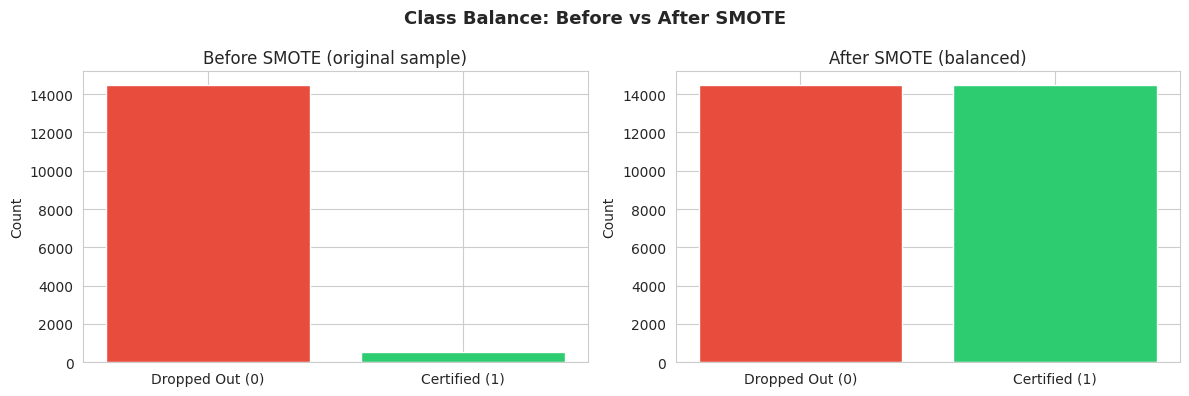

In [16]:
# Visualize how imbalanced the data was and how SMOTE fixed it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
axes[0].bar(['Dropped Out (0)', 'Certified (1)'],
            [14464, 536], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Before SMOTE (original sample)')
axes[0].set_ylabel('Count')

# After SMOTE
axes[1].bar(['Dropped Out (0)', 'Certified (1)'],
            [14464, 14464], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('After SMOTE (balanced)')
axes[1].set_ylabel('Count')

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

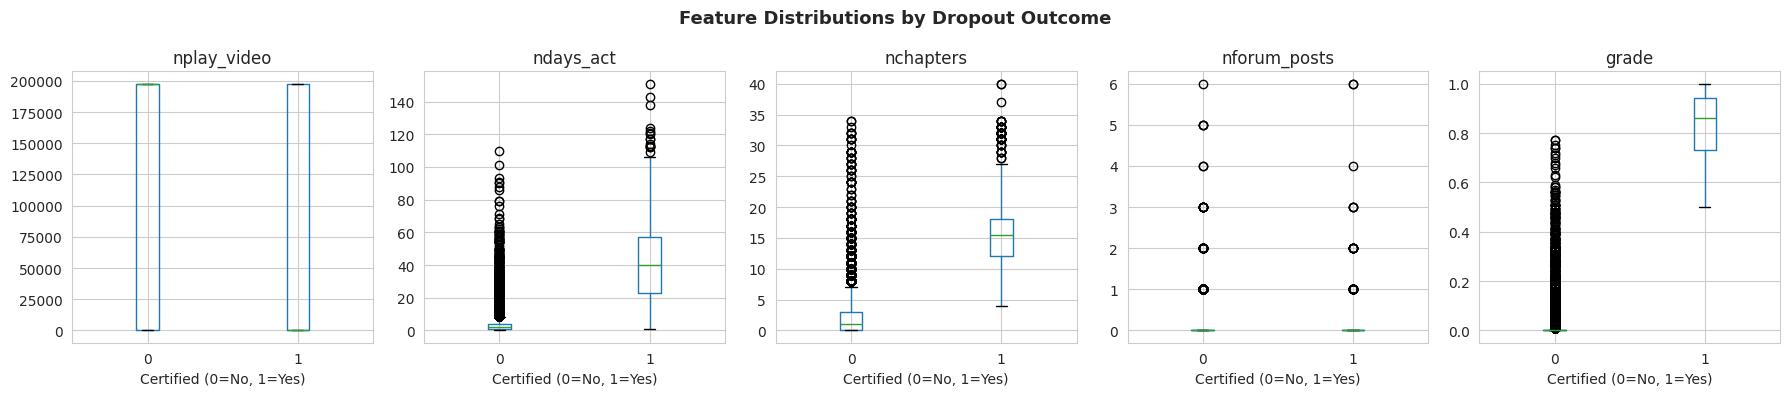

In [17]:
# checking how they differ by outcome
features = ['nplay_video', 'ndays_act', 'nchapters', 'nforum_posts', 'grade']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feat in enumerate(features):
    df_sample.boxplot(column=feat, by='certified', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Certified (0=No, 1=Yes)')

plt.suptitle('Feature Distributions by Dropout Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

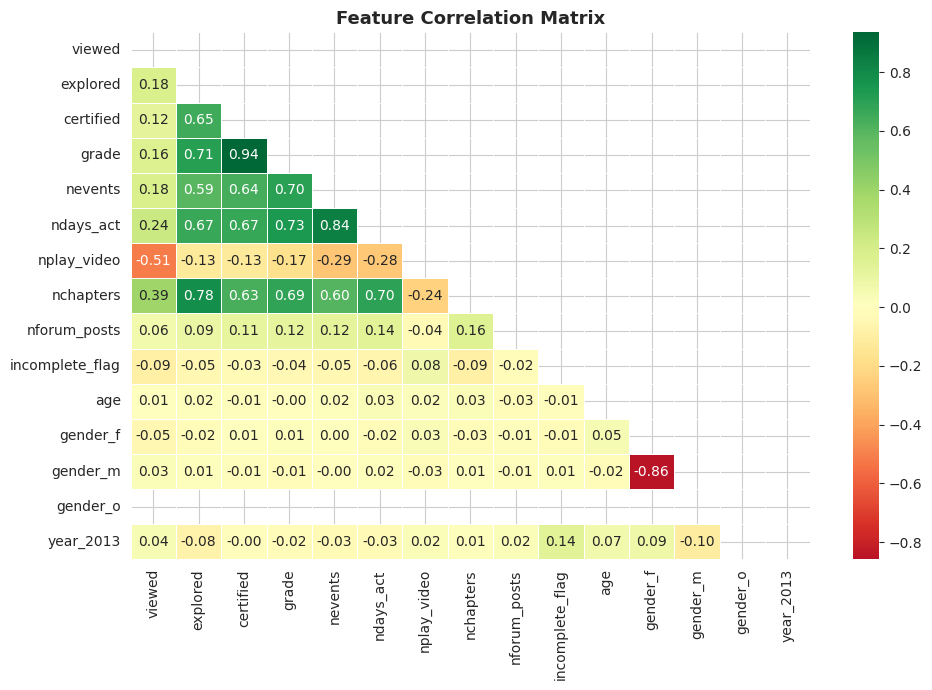

In [18]:
# Shows how features relate to each other and to certification(Strong correlation with 'certified' = useful predictor)
plt.figure(figsize=(10, 7))
corr = df_sample.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (it's a mirror)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Experiment 1

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Logistic Regression — simple, interpretable baseline model
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Dropout', 'Certified']))

=== Logistic Regression ===
Accuracy: 0.9711
AUC-ROC:  0.9931

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.98      0.96      0.97      2893
   Certified       0.96      0.98      0.97      2893

    accuracy                           0.97      5786
   macro avg       0.97      0.97      0.97      5786
weighted avg       0.97      0.97      0.97      5786



Experiment 2

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — stronger, handles non-linear patterns well
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Dropout', 'Certified']))

=== Random Forest ===
Accuracy: 0.9898
AUC-ROC:  0.9989

Classification Report:
              precision    recall  f1-score   support

     Dropout       1.00      0.98      0.99      2893
   Certified       0.98      1.00      0.99      2893

    accuracy                           0.99      5786
   macro avg       0.99      0.99      0.99      5786
weighted avg       0.99      0.99      0.99      5786



Experiment 3

In [21]:
# Same model, different hyperparameters — more trees, deeper, stricter leaf size(Systematic experimentation)
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf_tuned.fit(X_train_scaled, y_train)
rf_tuned_preds = rf_tuned.predict(X_test_scaled)
rf_tuned_probs = rf_tuned.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest (Tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, rf_tuned_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, rf_tuned_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_preds, target_names=['Dropout', 'Certified']))

=== Random Forest (Tuned) ===
Accuracy: 0.9888
AUC-ROC:  0.9986

Classification Report:
              precision    recall  f1-score   support

     Dropout       1.00      0.98      0.99      2893
   Certified       0.98      1.00      0.99      2893

    accuracy                           0.99      5786
   macro avg       0.99      0.99      0.99      5786
weighted avg       0.99      0.99      0.99      5786



Feature Importance

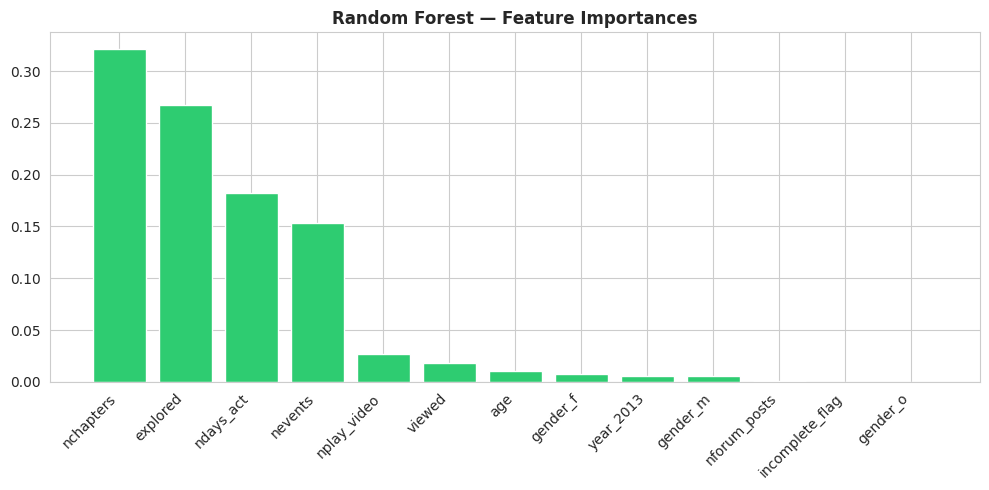

In [22]:
# Which features does Random Forest think matter most?
feat_names = X_train.columns.tolist()
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feat_names)), importances[indices], color='#2ecc71')
plt.xticks(range(len(feat_names)), [feat_names[i] for i in indices], rotation=45, ha='right')
plt.title('Random Forest — Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Tensorflow setup & tf.data pipeline

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(SEED)

# tf.data is TensorFlow's efficient data pipeline — loads data in batches
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values)) \
    .shuffle(buffer_size=1000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test.values)) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow version:", tf.__version__)
print("Train batches:", len(train_ds), "| Test batches:", len(test_ds))

TensorFlow version: 2.20.0
Train batches: 362 | Test batches: 91


Sequential model (Experiment 4)

In [24]:
# Sequential API — simplest way to stack layers one after another
# Dropout layers randomly turn off neurons during training to prevent overfitting
seq_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # sigmoid = probability between 0 and 1
], name="Sequential_Model")

seq_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

seq_model.summary()

Model: "Sequential_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Training Sequential Model



In [25]:
# Train for up to 50 epochs but stop early if validation loss stops improving (saves time & prevents overfitting)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

seq_history = seq_model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete.")

Epoch 1/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9496 - loss: 0.1620 - val_accuracy: 0.9720 - val_loss: 0.0863
Epoch 2/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9714 - loss: 0.0921 - val_accuracy: 0.9753 - val_loss: 0.0808
Epoch 3/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9742 - loss: 0.0871 - val_accuracy: 0.9748 - val_loss: 0.0774
Epoch 4/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0827 - val_accuracy: 0.9761 - val_loss: 0.0748
Epoch 5/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.0798 - val_accuracy: 0.9770 - val_loss: 0.0740
Epoch 6/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0781 - val_accuracy: 0.9784 - val_loss: 0.0712
Epoch 7/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0760 - val_accuracy: 0.9782 - val_loss: 0.0710
Epoch 8/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0750 - val_accuracy: 0

Evaluating Sequential Model

In [26]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

seq_probs = seq_model.predict(X_test_scaled).flatten()
seq_preds = (seq_probs > 0.5).astype(int)

print("=== Sequential Model (Experiment 4) ===")
print(f"Accuracy: {accuracy_score(y_test, seq_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, seq_probs):.4f}")
print(classification_report(y_test, seq_preds, target_names=['Dropout', 'Certified']))

181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Sequential Model (Experiment 4) ===
Accuracy: 0.9841
AUC-ROC:  0.9958
              precision    recall  f1-score   support

     Dropout       1.00      0.97      0.98      2893
   Certified       0.97      1.00      0.98      2893

    accuracy                           0.98      5786
   macro avg       0.98      0.98      0.98      5786
weighted avg       0.98      0.98      0.98      5786



Sequential Learning Curve

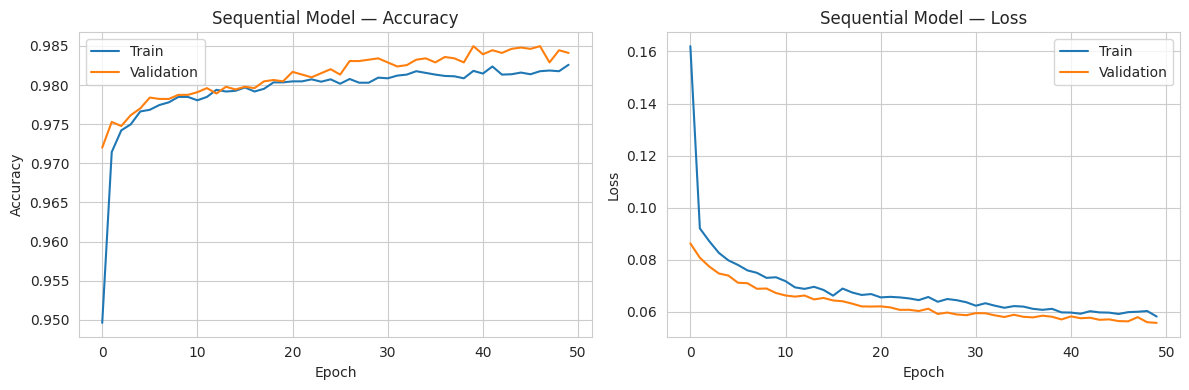

In [27]:
# Learning curves show how the model improved over each training epoch
# If train and val curves are close together = good. Big gap = overfitting
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(seq_history.history['accuracy'], label='Train')
plt.plot(seq_history.history['val_accuracy'], label='Validation')
plt.title('Sequential Model — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(seq_history.history['loss'], label='Train')
plt.plot(seq_history.history['val_loss'], label='Validation')
plt.title('Sequential Model — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('seq_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Functional API Model (Experiment 5)

In [28]:
# Functional API — more flexible than Sequential, allows branching paths
# We use two parallel branches that process features differently then merge
inputs = keras.Input(shape=(X_train_scaled.shape[1],))

# Branch 1 — deeper path
x1 = layers.Dense(64, activation='relu')(inputs)
x1 = layers.Dropout(0.3)(x1)
x1 = layers.Dense(32, activation='relu')(x1)

# Branch 2 — shorter path (acts as a shortcut connection)
x2 = layers.Dense(32, activation='relu')(inputs)

# Merging both branches — the model learns from both paths simultaneously
merged = layers.Concatenate()([x1, x2])
merged = layers.Dense(16, activation='relu')(merged)
outputs = layers.Dense(1, activation='sigmoid')(merged)

func_model = keras.Model(inputs=inputs, outputs=outputs, name="Functional_Model")

func_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

func_model.summary()

Model: "Functional_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        896 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        448 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         17 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

Train Functional Model

In [29]:
func_history = func_model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete.")

Epoch 1/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9465 - loss: 0.1597 - val_accuracy: 0.9753 - val_loss: 0.0831
Epoch 2/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9737 - loss: 0.0846 - val_accuracy: 0.9758 - val_loss: 0.0779
Epoch 3/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0798 - val_accuracy: 0.9775 - val_loss: 0.0741
Epoch 4/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.0763 - val_accuracy: 0.9772 - val_loss: 0.0730
Epoch 5/50
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0730 - val_accuracy: 0.9786 - val_loss: 0.0691
Training complete.


Evaluate Functional Model

In [30]:
func_probs = func_model.predict(X_test_scaled).flatten()
func_preds = (func_probs > 0.5).astype(int)

print("=== Functional Model (Experiment 5) ===")
print(f"Accuracy: {accuracy_score(y_test, func_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, func_probs):.4f}")
print(classification_report(y_test, func_preds, target_names=['Dropout', 'Certified']))

181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Functional Model (Experiment 5) ===
Accuracy: 0.9753
AUC-ROC:  0.9936
              precision    recall  f1-score   support

     Dropout       0.99      0.96      0.97      2893
   Certified       0.96      0.99      0.98      2893

    accuracy                           0.98      5786
   macro avg       0.98      0.98      0.98      5786
weighted avg       0.98      0.98      0.98      5786



Functional Learning Curve

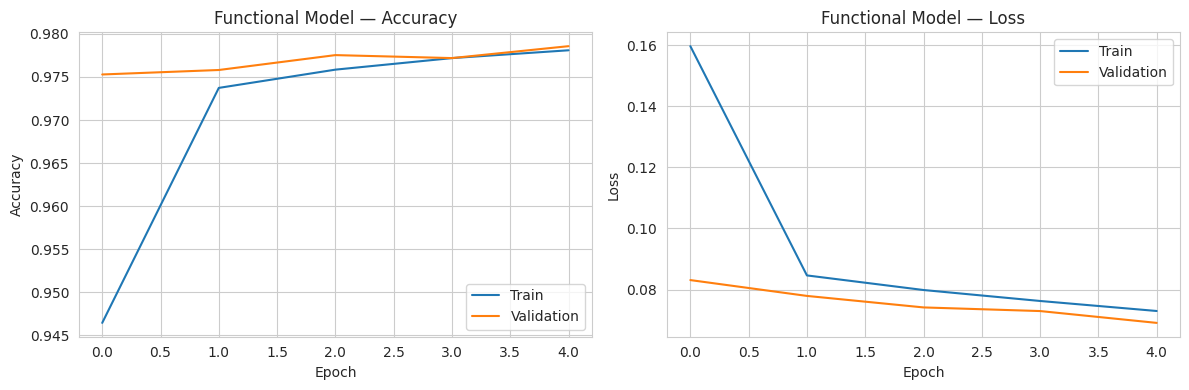

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(func_history.history['accuracy'], label='Train')
plt.plot(func_history.history['val_accuracy'], label='Validation')
plt.title('Functional Model — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(func_history.history['loss'], label='Train')
plt.plot(func_history.history['val_loss'], label='Validation')
plt.title('Functional Model — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('func_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Confusion Matrices (All Models)

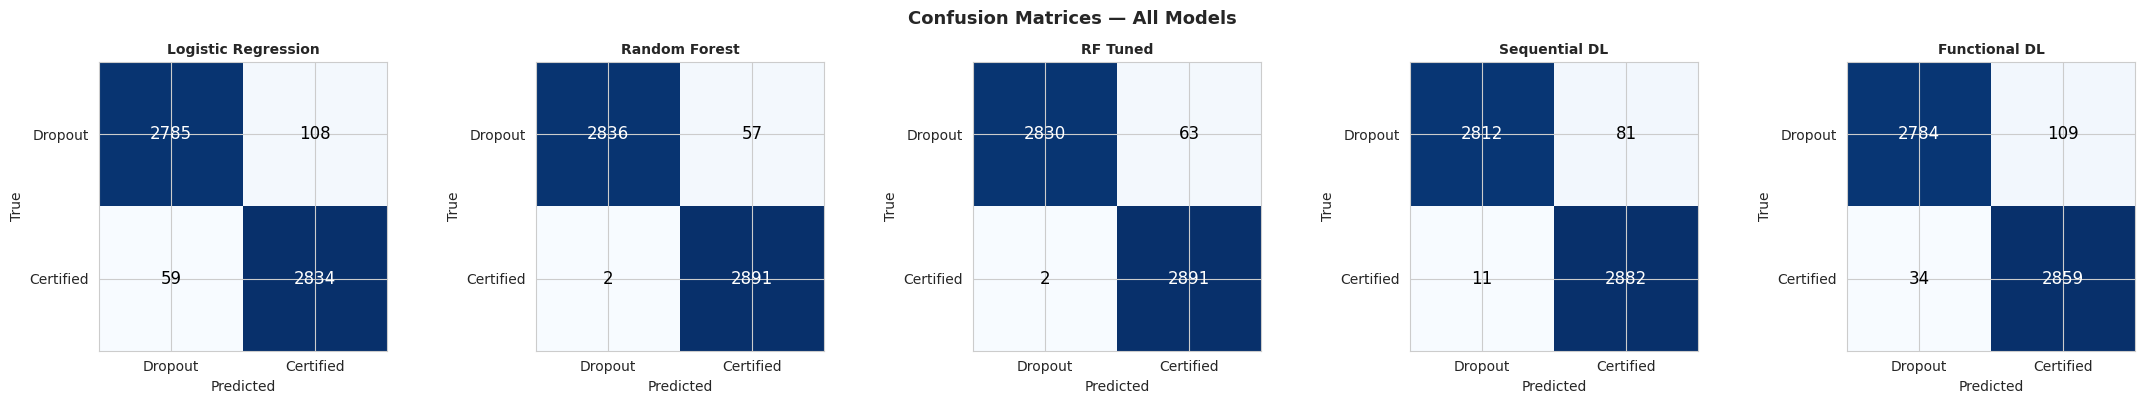

In [32]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Dropout', 'Certified'])
    ax.set_yticklabels(['Dropout', 'Certified'])
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
plot_cm(axes[0], y_test, lr_preds,        'Logistic Regression')
plot_cm(axes[1], y_test, rf_preds,        'Random Forest')
plot_cm(axes[2], y_test, rf_tuned_preds,  'RF Tuned')
plot_cm(axes[3], y_test, seq_preds,       'Sequential DL')
plot_cm(axes[4], y_test, func_preds,      'Functional DL')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

ROC Curves (All Models)

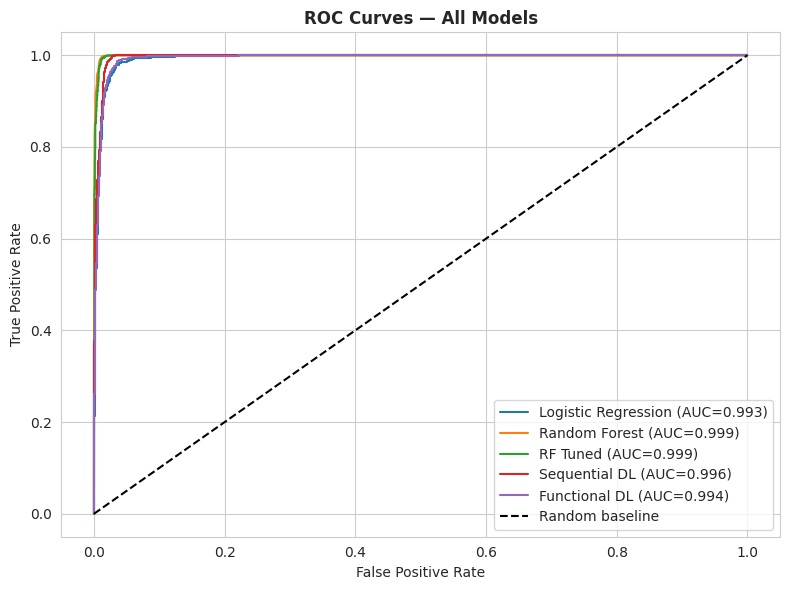

In [33]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

models = {
    'Logistic Regression': lr_probs,
    'Random Forest':       rf_probs,
    'RF Tuned':            rf_tuned_probs,
    'Sequential DL':       seq_probs,
    'Functional DL':       func_probs,
}

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Final Results Summary Table

In [34]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'RF Tuned',
              'Sequential DL', 'Functional DL'],
    'Type': ['Classical ML', 'Classical ML', 'Classical ML',
             'Deep Learning', 'Deep Learning'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, rf_tuned_preds),
        accuracy_score(y_test, seq_preds),
        accuracy_score(y_test, func_preds),
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, rf_tuned_probs),
        roc_auc_score(y_test, seq_probs),
        roc_auc_score(y_test, func_probs),
    ]
})

results['Accuracy'] = results['Accuracy'].round(4)
results['AUC-ROC']  = results['AUC-ROC'].round(4)

print(results.to_string(index=False))
results

              Model          Type  Accuracy  AUC-ROC
Logistic Regression  Classical ML    0.9711   0.9931
      Random Forest  Classical ML    0.9898   0.9989
           RF Tuned  Classical ML    0.9888   0.9986
      Sequential DL Deep Learning    0.9841   0.9958
      Functional DL Deep Learning    0.9753   0.9936


,Model,Type,Accuracy,AUC-ROC
0,Logistic Regression,Classical ML,0.9711,0.9931
1,Random Forest,Classical ML,0.9898,0.9989
2,RF Tuned,Classical ML,0.9888,0.9986
3,Sequential DL,Deep Learning,0.9841,0.9958
4,Functional DL,Deep Learning,0.9753,0.9936


Error Analysis

In [35]:
# This helps us understand WHERE the model struggles
test_df = X_test.copy()
test_df['true_label']      = y_test.values
test_df['predicted_label'] = rf_preds
test_df['correct']         = (test_df['true_label'] == test_df['predicted_label'])

errors = test_df[test_df['correct'] == False]
correct = test_df[test_df['correct'] == True]

print(f"Total errors: {len(errors)} out of {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)")
print(f"\nAverage activity (ndays_act) — Errors vs Correct predictions:")
print(f"  Misclassified: {errors['ndays_act'].mean():.2f}")
print(f"  Correct:       {correct['ndays_act'].mean():.2f}")
print(f"\nAverage chapters (nchapters) — Errors vs Correct:")
print(f"  Misclassified: {errors['nchapters'].mean():.2f}")
print(f"  Correct:       {correct['nchapters'].mean():.2f}")

Total errors: 59 out of 5786 (1.0%)

Average activity (ndays_act) — Errors vs Correct predictions:
  Misclassified: 25.75
  Correct:       23.27

Average chapters (nchapters) — Errors vs Correct:
  Misclassified: 14.14
  Correct:       9.18
